In [1]:
!pip install xgboost

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt

# Dosyayı okuma
df = pd.read_csv('/content/sample_data/df_model_final.csv')

# True/False formatındaki sütunları 1/0 formatına çevirme
bool_cols = df.select_dtypes(include=['bool']).columns
df[bool_cols] = df[bool_cols].astype(int)

# Bağımsız değişkenleri (X) ve hedef değişkeni (Target - y) ayırma
X = df.drop('Target', axis=1)
y = df['Target']

# Veriyi %80 Eğitim, %20 Test olarak bölme (stratify ile sınıf dengesini koruyarak)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Eğitim seti boyutu:", X_train.shape)
print("Test seti boyutu:", X_test.shape)

Eğitim seti boyutu: (5636, 16)
Test seti boyutu: (1410, 16)


In [4]:
# Sınıf dengesizliğini gidermek için scale_pos_weight hesaplama
scale_pos_weight_value = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

# XGBoost modelini tanımlama
model = XGBClassifier(
    n_estimators=1000,          # CatBoost'taki iterations parametresinin karşılığı
    learning_rate=0.05,
    max_depth=6,                # CatBoost'taki depth parametresinin karşılığı
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight_value, # auto_class_weights='Balanced' karşılığı
    random_state=42,
    early_stopping_rounds=50    # 50 adım boyunca iyileşme olmazsa eğitimi durdurur
)

# Modeli eğitme
print("Model eğitimi başlıyor...")
model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)], # Test seti üzerinde validasyon
    verbose=100                  # Her 100 iterasyonda bir süreci ekrana basar
)

# Test seti üzerinde tahmin yapma
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# Sonuçları yazdırma
print("\n--- Model Değerlendirme Sonuçları ---")
print(classification_report(y_test, y_pred))
print("ROC-AUC Skoru:", roc_auc_score(y_test, y_prob))

from sklearn.metrics import f1_score

# Sadece Patojenik (1) sınıfı için F1-Skoru (Binary F1)
f1_binary = f1_score(y_test, y_pred)
print(f"F1-Skoru (Sadece 1. Sınıf için): {f1_binary:.4f}")

# Her iki sınıfın (0 ve 1) ortalamasını hesaba katan F1-Skoru (Weighted F1)
f1_weighted = f1_score(y_test, y_pred, average='weighted')
print(f"F1-Skoru (Ağırlıklı Ortalama): {f1_weighted:.4f}")

Model eğitimi başlıyor...
[0]	validation_0-auc:0.94928
[100]	validation_0-auc:0.97178
[200]	validation_0-auc:0.97343
[237]	validation_0-auc:0.97325

--- Model Değerlendirme Sonuçları ---
              precision    recall  f1-score   support

           0       0.93      0.89      0.91       705
           1       0.89      0.94      0.91       705

    accuracy                           0.91      1410
   macro avg       0.91      0.91      0.91      1410
weighted avg       0.91      0.91      0.91      1410

ROC-AUC Skoru: 0.9735315124993712
F1-Skoru (Sadece 1. Sınıf için): 0.9148
F1-Skoru (Ağırlıklı Ortalama): 0.9127


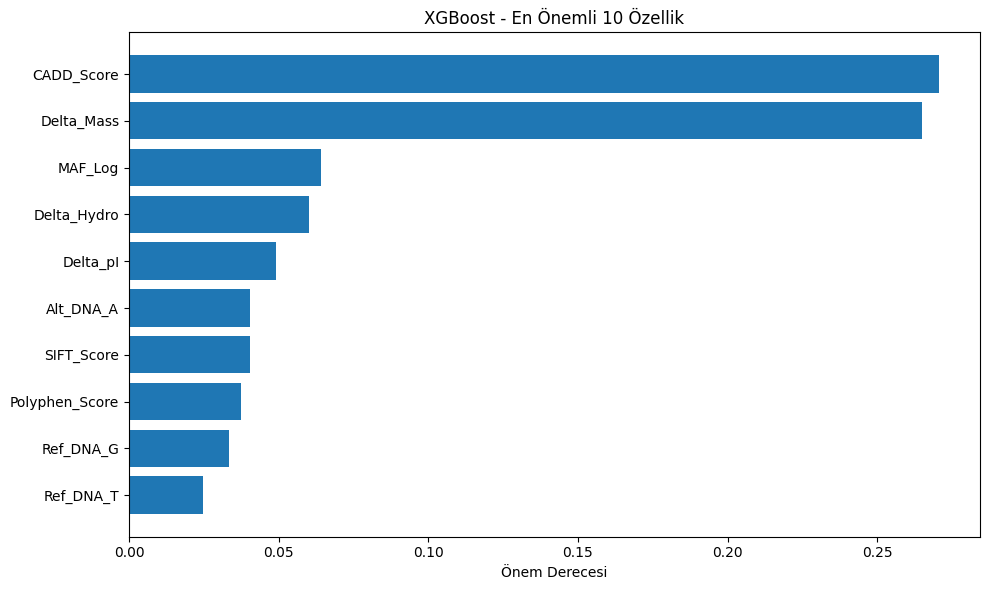

In [5]:
# En önemli 10 özelliği görselleştirme
feature_importance = model.feature_importances_
sorted_idx = feature_importance.argsort()[-10:] # En yüksek etkiye sahip son 10 özellik

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_idx)), feature_importance[sorted_idx], align='center')
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx])
plt.title('XGBoost - En Önemli 10 Özellik')
plt.xlabel('Önem Derecesi')
plt.tight_layout()
plt.show()

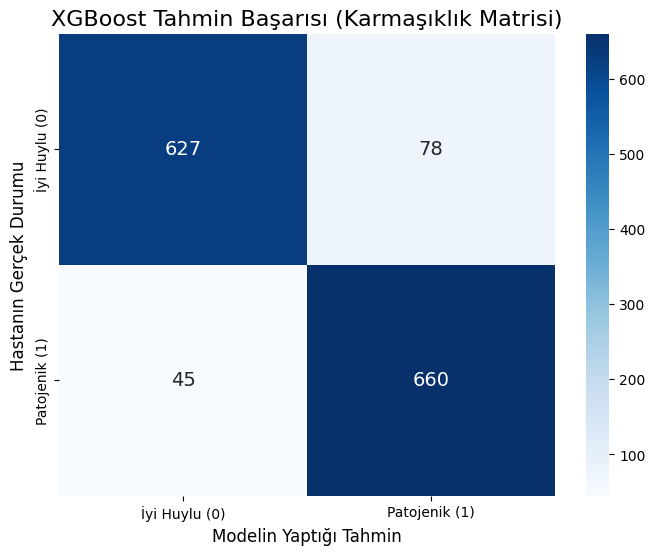

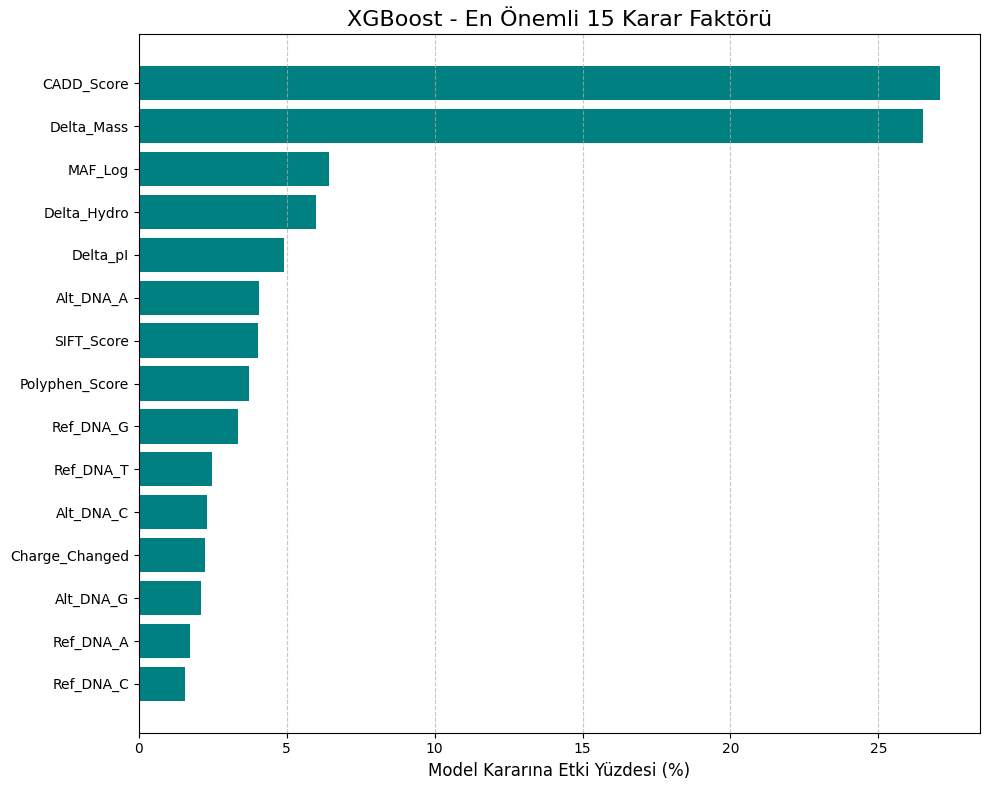

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

# ---------------------------------------------------------
# 1. KARMAŞIKLIK MATRİSİ (CONFUSION MATRIX) GÖRSELLEŞTİRME
# ---------------------------------------------------------
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)

# Isı haritası (Heatmap) ile şık bir çizim
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['İyi Huylu (0)', 'Patojenik (1)'],
            yticklabels=['İyi Huylu (0)', 'Patojenik (1)'],
            annot_kws={"size": 14}) # Yazı boyutunu büyütelim

plt.title('XGBoost Tahmin Başarısı (Karmaşıklık Matrisi)', fontsize=16)
plt.xlabel('Modelin Yaptığı Tahmin', fontsize=12)
plt.ylabel('Hastanın Gerçek Durumu', fontsize=12)
plt.show()

print("\n" + "="*50 + "\n")

# ---------------------------------------------------------
# 2. ÖZELLİK ÖNEMİ (FEATURE IMPORTANCE) GÖRSELLEŞTİRME
# ---------------------------------------------------------
plt.figure(figsize=(10, 8))

# XGBoost modelinin özellik önem derecelerini çekme ve 100 ile çarparak yüzdeye çevirme
feature_importances = model.feature_importances_ * 100

# En önemli 15 özelliği bulup sıralayalım (Özellik sayısı 15'ten azsa hata vermemesi için koruma ekledik)
top_n = min(15, len(X.columns))
sorted_idx = feature_importances.argsort()[-top_n:]

# Yatay bar grafiği çizimi
plt.barh(range(len(sorted_idx)), feature_importances[sorted_idx], color='teal', align='center')
plt.yticks(range(len(sorted_idx)), X.columns[sorted_idx], fontsize=10)
plt.title(f'XGBoost - En Önemli {top_n} Karar Faktörü', fontsize=16)
plt.xlabel('Model Kararına Etki Yüzdesi (%)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
# ── CELL 5 — KURULUM ──────────────────────────────────────
!pip install deap -q

import random
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from deap import base, creator, tools, algorithms
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import f1_score, make_scorer

f1_scorer = make_scorer(f1_score, average='macro')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("✅ Kütüphaneler yüklendi")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 4.7 MB/s eta 0:00:00
✅ Kütüphaneler yüklendi


In [8]:
# ── CELL 6 — FITNESS FONKSİYONU ───────────────────────────
def evaluate_xgboost(individual):
    lr        = float(np.clip(individual[0], 0.01, 0.30))
    max_depth = int(np.clip(round(individual[1]), 3, 10))

    model = XGBClassifier(
        n_estimators=300,
        learning_rate=lr,
        max_depth=max_depth,
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight_value,  # arkadaşın hesapladığı değer
        random_state=42,
        verbosity=0
    )
    score = cross_val_score(
        model, X, y, cv=cv, scoring=f1_scorer
    ).mean()
    return (score,)

In [9]:
# ── CELL 7 — GA KURULUMU ──────────────────────────────────
creator.create("FitnessMax", base.Fitness, weights=(1.0,))
creator.create("Individual", list, fitness=creator.FitnessMax)

toolbox = base.Toolbox()
toolbox.register("attr_lr",        random.uniform, 0.01, 0.30)
toolbox.register("attr_max_depth", random.uniform, 3.0,  10.0)
toolbox.register("individual", tools.initCycle, creator.Individual,
                 (toolbox.attr_lr, toolbox.attr_max_depth), n=1)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)
toolbox.register("evaluate",   evaluate_xgboost)
toolbox.register("mate",       tools.cxBlend, alpha=0.5)
toolbox.register("mutate",     tools.mutGaussian, mu=0, sigma=0.05, indpb=0.5)
toolbox.register("select",     tools.selTournament, tournsize=3)

print("✅ GA toolbox hazır")

✅ GA toolbox hazır


In [10]:
# ── CELL 8 — GA ÇALIŞTIR ──────────────────────────────────
print("🧬 Genetik Algoritma başlıyor...")
print("   Optimize edilen parametreler: learning_rate, max_depth")
print("   Fitness fonksiyonu: 5-fold CV Makro F1")
print("─" * 50)

pop   = toolbox.population(n=20)
hof   = tools.HallOfFame(1)
stats = tools.Statistics(lambda ind: ind.fitness.values)
stats.register("max_f1", np.max)
stats.register("avg_f1", np.mean)

pop, log = algorithms.eaSimple(
    pop, toolbox,
    cxpb=0.6,
    mutpb=0.3,
    ngen=15,
    stats=stats,
    halloffame=hof,
    verbose=True
)

🧬 Genetik Algoritma başlıyor...
   Optimize edilen parametreler: learning_rate, max_depth
   Fitness fonksiyonu: 5-fold CV Makro F1
──────────────────────────────────────────────────
gen	nevals	max_f1  	avg_f1  
0  	20    	0.917097	0.912734
1  	14    	0.916243	0.913682
2  	16    	0.916524	0.914652
3  	12    	0.916949	0.915608
4  	14    	0.917659	0.915857
5  	16    	0.917659	0.916183
6  	12    	0.917659	0.91556 
7  	12    	0.917659	0.916233
8  	16    	0.91766 	0.91641 
9  	15    	0.91766 	0.915815
10 	12    	0.917659	0.916085
11 	17    	0.917659	0.916106
12 	10    	0.917659	0.916801
13 	15    	0.917659	0.916978
14 	19    	0.917659	0.917042
15 	12    	0.917805	0.917482


In [11]:
# ── CELL 9 — SONUÇLAR ─────────────────────────────────────
best          = hof[0]
best_lr       = float(np.clip(best[0], 0.01, 0.30))
best_lr       = round(best_lr, 4)
best_maxdepth = int(np.clip(round(best[1]), 3, 10))
best_f1       = best.fitness.values[0]

# Baseline: arkadaşın orijinal parametreleri
baseline_f1 = cross_val_score(
    XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        eval_metric='auc',
        scale_pos_weight=scale_pos_weight_value,
        random_state=42,
        verbosity=0
    ),
    X, y, cv=cv, scoring=f1_scorer
).mean()

print("\n" + "="*50)
print("📊 GA OPTİMİZASYON SONUÇLARI")
print("="*50)
print(f"  Baseline  → lr=0.0500, max_depth=6          | Makro F1: {baseline_f1:.4f}")
print(f"  GA Sonucu → lr={best_lr}, max_depth={best_maxdepth}  | Makro F1: {best_f1:.4f}")
print(f"  İyileşme  → +{(best_f1 - baseline_f1):.4f}")
print("="*50)


📊 GA OPTİMİZASYON SONUÇLARI
  Baseline  → lr=0.0500, max_depth=6          | Makro F1: 0.9167
  GA Sonucu → lr=0.0214, max_depth=7  | Makro F1: 0.9178
  İyileşme  → +0.0011


In [12]:
# ── CELL 10 — OPTİMİZE MODEL İLE FINAL EĞİTİM ────────────
final_model = XGBClassifier(
    n_estimators=1000,
    learning_rate=best_lr,
    max_depth=best_maxdepth,
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight_value,
    early_stopping_rounds=50,
    random_state=42,
    verbosity=0
)

final_model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    verbose=100
)

y_pred_ga = final_model.predict(X_test)
y_prob_ga = final_model.predict_proba(X_test)[:, 1]

print("\n--- GA ile Optimize Edilmiş XGBoost Sonuçları ---")
print(classification_report(y_test, y_pred_ga))
print("ROC-AUC:", round(roc_auc_score(y_test, y_prob_ga), 4))
print("Makro F1:", round(f1_score(y_test, y_pred_ga, average='macro'), 4))

[0]	validation_0-auc:0.95524
[100]	validation_0-auc:0.96969
[200]	validation_0-auc:0.97231
[300]	validation_0-auc:0.97367
[359]	validation_0-auc:0.97359

--- GA ile Optimize Edilmiş XGBoost Sonuçları ---
              precision    recall  f1-score   support

           0       0.94      0.89      0.91       705
           1       0.90      0.94      0.92       705

    accuracy                           0.92      1410
   macro avg       0.92      0.92      0.92      1410
weighted avg       0.92      0.92      0.92      1410

ROC-AUC: 0.9738
Makro F1: 0.9156
